# DSN Mart Sales Prediction

This Notebook is by Alegbeleye Opeyemi Micheal for the DSN Qualification Hackathon 2026 - ML Track.

**Library Requirements**
1. catboost
2. lightgbm
3. xgboost
4. ydata-profiling (only if you want the profile report)

**Contents**
1. Loading the data
2. Understanding the data
3. Testing my hypotheses
4. Encoding for models that need it
5. Data cleaning and feature engineering
6. CatBoost
7. LightGBM
8. Random Forest
9. XGBoost
10. Stacking
11. Summary of results

##  Loading the data

In [176]:
# Provided with both the train and test data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#other imports performed..
from ydata_profiling import ProfileReport




test_data = pd.read_csv('/kaggle/input/datasets/opeyemialegbeleye111/opoiujytrf/test.csv')
training_data = pd.read_csv('/kaggle/input/datasets/opeyemialegbeleye111/opoiujytrf/train.csv')

## Understanding the data

**Quick structural check: column names, data types, a preview of rows, and summary statistics**

In [177]:
#to get a good view of the data
report = ProfileReport(training_data)
report.to_notebook_iframe()

print(training_data.columns)
print(training_data.head())
print(training_data.info())
print(training_data.describe())

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 38.90it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='object')
          id product_code  product_weight_kg fat_content  shelf_visibility  \
0  row_00000   PRD-PRFP9S             14.252     Low Fat            0.0271   
1  row_00001   PRD-PXXK71              7.698     Low Fat            0.0720   
2  row_00002   PRD-V5MOIJ             14.264     Regular            0.0421   
3  row_00003   PRD-UN5Z3J                NaN     Regular            0.0449   
4  row_00004   PRD-6RDQYB             10.338     Regular            0.0120   

     product_category  product_price store_code  store_age_years store_size  \
0        Frozen Foods          81.37  STORE-AGY               45      Large   
1  HEALTH AND HYGIENE          42.05  STORE-YLW               35      Small   
2              Canned      

To get better info on the dataset I use the "ydata_profiling" library

In [178]:
print(training_data.isna().sum())
print(test_data.isna().sum())

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


Now I have a very good view of the data.

Categorical columns are
1. store_size
2. product_category
3. fat_content
4. store_code
5. store_location_tier
6. store_format

The columns **id, product_code, store_code, fat_content, shelf_visibility, product_category, product_price, store_age_years, total_sales, store_format and store_location_tier** have no missing values. The columns with missing values are **product_weight_kg and store_size**, and the test data has the same two. There are no duplicated ids.

## Testing my hypotheses

In [179]:
#confirming suspicions based on personal inspection of the data..
#relationship between product code and product category

by_code = training_data.groupby('product_code')['product_category']
print('product codes with one category (raw labels)    :', round((by_code.nunique() == 1).mean(), 3))
print('product codes with one category (cleaned labels):',
      round((training_data['product_category'].str.lower().str.strip().groupby(training_data['product_code']).nunique() == 1).mean(), 3))
print('raw category labels:', training_data['product_category'].nunique())
print('cleaned category labels:', training_data['product_category'].str.lower().str.strip().nunique())
print('there are', training_data['product_code'].nunique(), 'unique product codes')
print('there are', training_data['store_code'].nunique(), 'unique store codes')

product codes with one category (raw labels)    : 0.105
product codes with one category (cleaned labels): 1.0
raw category labels: 48
cleaned category labels: 16
there are 1555 unique product codes
there are 10 unique store codes


Insights
1. A product code always belongs to one product category, but only once the letter casing is fixed. The 48 raw labels are really 16 categories ("Dairy", "DAIRY" and "dairy" are the same category).
2. There are only 10 unique store codes in the whole data.
3. With this I have a hypothesis that each product category will have a particular fat content.

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

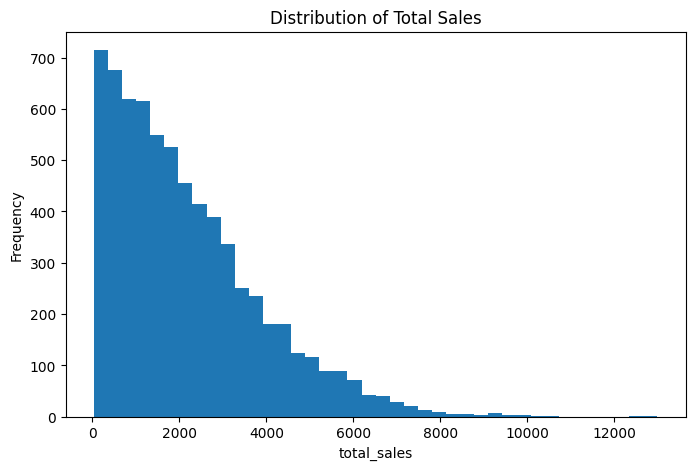

In [180]:
display(training_data["total_sales"].describe())

plt.figure(figsize=(8, 5))
plt.hist(training_data["total_sales"], bins=40)
plt.title("Distribution of Total Sales")
plt.xlabel("total_sales")
plt.ylabel("Frequency")
plt.show()

Total sales is right skewed. Most rows are below 3,000 but a few go as high as about 13,000.

In [181]:
#confirming my hypotheses
# firstly a mini data cleaning is done on only the product category column..

training_data['product_category'] = training_data['product_category'].str.lower().str.strip()

pd.set_option('display.max_colwidth', None)
print(training_data.groupby('fat_content')['product_category'].unique())

fat_content
Low Fat    [frozen foods, health and hygiene, soft drinks, canned, baking goods, household, snack foods, dairy, fruits and vegetables, meat, seafood, breakfast, breads, others, hard drinks, starchy foods]
Regular                                                        [canned, soft drinks, meat, snack foods, baking goods, dairy, fruits and vegetables, breakfast, frozen foods, breads, starchy foods, seafood]
Name: product_category, dtype: object


The hypothesis turned out to be false. The same product category can have different fat content.

**Another hypothesis**: "if the same product category has different fat content, how does it affect the product price?"

In [182]:
print(training_data.groupby('product_category')['fat_content'].value_counts().unstack())

fat_content            Low Fat  Regular
product_category                       
baking goods             263.0    253.0
breads                   121.0     88.0
breakfast                 30.0     55.0
canned                   265.0    252.0
dairy                    345.0    209.0
frozen foods             358.0    317.0
fruits and vegetables    509.0    497.0
hard drinks              169.0      NaN
health and hygiene       412.0      NaN
household                740.0      NaN
meat                     144.0    195.0
others                   132.0      NaN
seafood                   31.0     21.0
snack foods              538.0    395.0
soft drinks              306.0     60.0
starchy foods             62.0     51.0


Categories representing non-food or ambiguous items: **household, health and hygiene, hard drinks, and others** show 100% Low Fat with zero Regular entries. This strongly suggests fat_content was defaulted for these rather than genuinely measured, since the real food categories all show a natural mix of both values.

In [183]:
print(training_data.groupby('product_category')['product_price'].agg(['mean', 'min', 'max']).round(1))
print(training_data.groupby('fat_content')['product_price'].mean().round(1))

                        mean   min    max
product_category                         
baking goods           125.7  33.2  264.7
breads                 140.5  31.6  270.9
breakfast              140.8  39.3  240.2
canned                 138.1  37.1  269.4
dairy                  148.7  33.1  271.8
frozen foods           138.1  31.5  270.6
fruits and vegetables  143.7  35.5  269.0
hard drinks            138.4  33.8  264.2
health and hygiene     128.8  32.4  273.0
household              149.3  32.4  268.7
meat                   143.5  34.2  262.2
others                 134.3  34.5  258.4
seafood                139.8  34.2  236.3
snack foods            145.1  32.0  268.1
soft drinks            129.1  31.1  269.9
starchy foods          148.5  35.3  268.5
fat_content
Low Fat    140.1
Regular    141.1
Name: product_price, dtype: float64


Prices cover the same range in every category and fat content does not change the average price. Price varies more within a category than between categories.

In [184]:
print('there are', training_data['store_code'].isna().sum(),
      'missing values in the store code column')
print(training_data['store_code'].value_counts())
print(training_data.groupby('store_code')['store_size'].nunique())

there are 0 missing values in the store code column
store_code
STORE-YLW    754
STORE-9RG    752
STORE-AGY    748
STORE-7WS    748
STORE-OYG    744
STORE-HL7    742
STORE-DKU    736
STORE-89Z    728
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64
store_code
STORE-7WS    1
STORE-89Z    1
STORE-9RG    1
STORE-AGY    1
STORE-DKU    0
STORE-HL7    1
STORE-JOR    0
STORE-OYG    0
STORE-T5G    1
STORE-YLW    1
Name: store_size, dtype: int64


It was discovered that
1. there are no NaN store codes and there are only 10 different store codes.
2. 7 of the 10 stores have a consistent, single size; the remaining 3 (STORE-DKU, STORE-JOR, STORE-OYG) have no size value at all, so it cannot be recovered.

Hypotheses: "does a particular store sell a particular product", "does a particular store sell more of a product", "does a particular store have more sales".

In [185]:
print(training_data.groupby('store_code').agg(store_format=('store_format', 'first'),
                                              store_location_tier=('store_location_tier', 'first'),
                                              store_age_years=('store_age_years', 'nunique'),
                                              mean_sales=('total_sales', 'mean')).sort_values('mean_sales', ascending=False).round(0))

                    store_format store_location_tier  store_age_years  \
store_code                                                              
STORE-7WS   Flagship Hypermarket              Tier_3                1   
STORE-9RG   Standard Supermarket              Tier_2                1   
STORE-89Z   Standard Supermarket              Tier_1                1   
STORE-OYG   Standard Supermarket              Tier_2                1   
STORE-AGY   Standard Supermarket              Tier_3                1   
STORE-YLW   Standard Supermarket              Tier_1                1   
STORE-DKU   Standard Supermarket              Tier_2                1   
STORE-HL7             Superstore              Tier_3                1   
STORE-T5G            Corner Shop              Tier_1                1   
STORE-JOR            Corner Shop              Tier_3                1   

            mean_sales  
store_code              
STORE-7WS       3660.0  
STORE-9RG       2479.0  
STORE-89Z       2366.0 

Each store code has exactly one format and one tier, and one store age. So store_format, store_location_tier, store_size and store_age_years are all just different names for the same 10 stores.

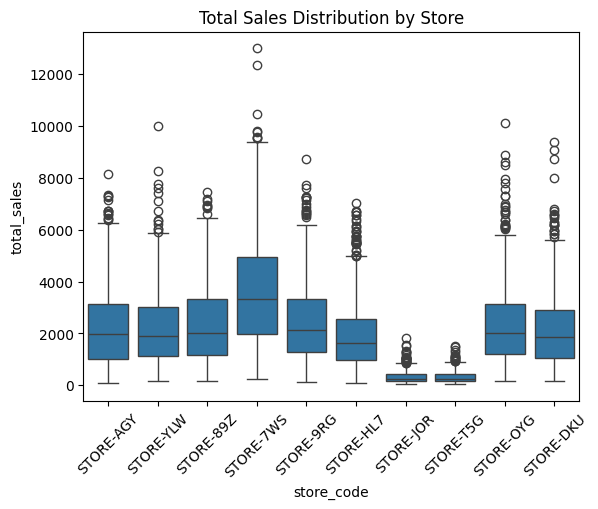

                   mean     min       max
store_code                               
STORE-7WS   3660.182219  243.24  12996.82
STORE-89Z   2365.926745  155.47   7477.67
STORE-9RG   2479.168098  117.76   8726.50
STORE-AGY   2254.890120   72.28   8141.49
STORE-DKU   2177.136481  147.20   9388.15
STORE-HL7   1971.661954   73.54   7016.22
STORE-JOR    334.435011   33.30   1830.37
STORE-OYG   2365.833656  149.73  10130.90
STORE-T5G    338.326651   32.70   1523.62
STORE-YLW   2253.950690  164.83   9999.51


In [186]:
sns.boxplot(data=training_data, x='store_code', y='total_sales')
plt.xticks(rotation=45)
plt.title('Total Sales Distribution by Store')
plt.show()
print(training_data.groupby('store_code')['total_sales'].agg(['mean', 'min', 'max']))

**Sales vary noticeably by store:**
some stores consistently sell more regardless of product, so store_code itself is a meaningful signal, not just a label. The two corner shops (STORE-JOR and STORE-T5G) sell about 6 to 7 times less than the other stores, and STORE-7WS (the flagship hypermarket) sells the most.

In [187]:
#seeing how store size affects total sales

training_data.groupby('store_size', dropna=False)['total_sales'].agg(['mean', 'min', 'max'])

,mean,min,max
store_size,,,
Large,2254.890120,72.28,8141.49
Medium,2670.506826,73.54,12996.82
Small,1918.405954,32.70,9999.51
NaN,1828.749171,33.30,10130.90


Contrary to what you would expect, store size doesn't scale predictably with sales: medium stores actually outsell large stores on average. This breaks the intuitive assumption that "bigger store = more sales". Size is just attached to particular stores, so store_format and store_code capture the real difference and store_size on its own is not a strong predictor.

In [188]:
#to check what product categories sell more..
training_data.groupby('product_category')['total_sales'].agg(['mean', 'min', 'max'])

,mean,min,max
product_category,,,
baking goods,1943.416860,36.15,7720.12
breads,2186.152871,34.56,9258.66
breakfast,1852.197765,39.63,7125.94
canned,2196.398743,37.76,8247.44
dairy,2238.317076,40.12,10477.97
frozen foods,2140.770133,35.40,9263.00
fruits and vegetables,2277.854672,46.65,12359.04
hard drinks,2189.723195,37.80,8141.49
health and hygiene,1996.266044,34.32,9999.51


Looking at the mean there are no notable conclusions to draw.

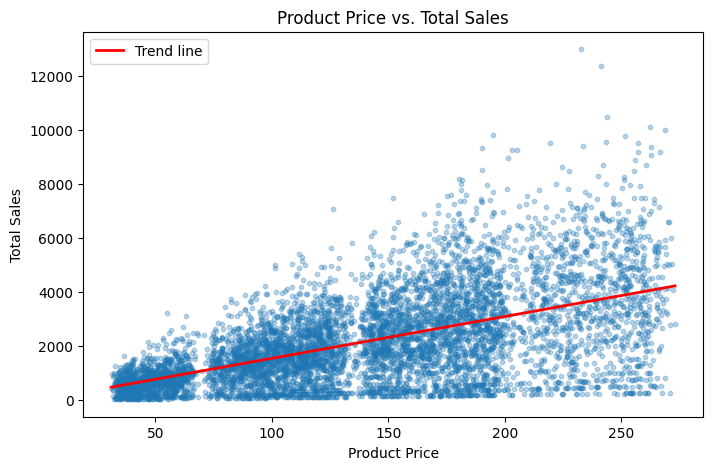

the correlation between the total sales and product price is 0.5698334561303247


In [189]:
#inspecting the product price and total sales

plt.figure(figsize=(8, 5))
plt.scatter(training_data['product_price'], training_data['total_sales'], alpha=0.3, s=10)

z = np.polyfit(training_data['product_price'], training_data['total_sales'], 1)
x_line = np.linspace(training_data['product_price'].min(), training_data['product_price'].max(), 100)
plt.plot(x_line, z[0]*x_line + z[1], color='red', linewidth=2, label='Trend line')

plt.xlabel('Product Price')
plt.ylabel('Total Sales')
plt.title('Product Price vs. Total Sales')
plt.legend()
plt.show()
print('the correlation between the total sales and product price is',
      training_data['product_price'].corr(training_data['total_sales']))

Product price shows a real, positive relationship with total sales. The correlation is approximately 0.57: as price increases, total sales tends to increase as well. This is a meaningfully stronger relationship than any other single numeric feature. However, it is far from perfect. The spread around the trend line gets wider as the price goes up, so price alone does not determine total_sales; the store is the other big factor.

In [190]:
#studying store location tier, store format as this could be factors that affect total sales..

print(training_data.groupby('store_location_tier')['total_sales'].agg(['mean', 'min', 'max']))
print(training_data.groupby('store_format')['total_sales'].agg(['mean', 'min', 'max']))
print(training_data['store_size'].isna().value_counts())

                            mean     min       max
store_location_tier                               
Tier_1               1868.171278   32.70   9999.51
Tier_2               2341.795296  117.76  10130.90
Tier_3               2254.114400   33.30  12996.82
                             mean     min       max
store_format                                       
Corner Shop            336.353868   32.70   1830.37
Flagship Hypermarket  3660.182219  243.24  12996.82
Standard Supermarket  2316.319677   72.28  10130.90
Superstore            1971.661954   73.54   7016.22
store_size
False    4899
True     1919
Name: count, dtype: int64


On the effect on total sales
1. tier 2 stores sell more than tier 3 and tier 1
2. flagship hypermarkets sell more than standard supermarkets, superstores and corner shops (superstores sell a little less than standard supermarkets)

Also, 3 different store codes have no store size all through the data. These are codes DKU, OYG and JOR.

##  Encoding for models that need it

Random Forest cannot handle categorical data, so it needs encoded data. The store location tier and the store format are ordinal encoded because of the ordering I noticed in the sales, and the other categories are one hot encoded.

In [191]:
encode_columns = ['fat_content', 'product_category', 'store_size']

train_encoded = training_data.copy()
test_encoded = test_data.copy()

#Ordinal Encoding because of the noticed ordering of the categories
tier_encoding = {
    'tier_1': 1,
    'tier_2': 3,
    'tier_3': 2
}

store_format_encoding = {
    'flagship hypermarket': 4,
    'standard supermarket': 3,
    'superstore': 2,
    'corner shop': 1
}

In [192]:
#data cleaning for models that need encoding

for cc in [train_encoded, test_encoded]:
    cc['store_location_tier'] = cc['store_location_tier'].str.strip().str.lower()
    cc['store_location_tier'] = cc['store_location_tier'].map(tier_encoding)
    cc['store_format'] = cc['store_format'].str.strip().str.lower().map(store_format_encoding)
    cc['store_size'] = cc['store_size'].transform(
        lambda x: x.fillna('unknown').str.strip().str.lower()
    )
    cc['product_category'] = cc['product_category'].str.lower().str.strip()

for cc in [train_encoded, test_encoded]:
    assert cc['store_location_tier'].notna().all() and cc['store_format'].notna().all()

In [193]:
#encoding necessary categorical columns for models that need encoding

train_encoded = pd.get_dummies(train_encoded, columns=encode_columns, dtype=int)
test_encoded = pd.get_dummies(test_encoded, columns=encode_columns, dtype=int)
test_encoded = test_encoded.reindex(columns=train_encoded.drop(columns='total_sales').columns, fill_value=0)

print(train_encoded.shape, test_encoded.shape)

(6818, 32) (1705, 31)


## Data cleaning and feature engineering

This is the cleaning for the models that do not need encoding (CatBoost, LightGBM, XGBoost).



In [194]:
all_data = pd.concat([training_data.assign(part='train'), test_data.assign(part='test')], ignore_index=True)
cc = all_data

cc['product_category'] = cc['product_category'].str.lower().str.strip()

cc['store_format'] = cc['store_format'].str.lower().str.strip()

cc['store_location_tier'] = cc['store_location_tier'].str.lower().str.strip()

cc['fat_content'] = cc['fat_content'].str.lower().str.strip()

cc['store_size'] = cc.groupby('store_code')['store_size'].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if x.notna().any() else x.fillna('unknown')
)

cc['store_size'] = cc['store_size'].str.strip().str.lower().fillna('unknown')

cc['product_weight_kg'] = cc.groupby('product_code')['product_weight_kg'].transform(
    lambda x: x.fillna(x.mean())
)

cc['product_weight_kg'] = cc['product_weight_kg'].fillna(cc['product_weight_kg'].mean())

cc['shelf_visibility'] = cc['shelf_visibility'].replace(0, np.nan)

cc['shelf_visibility'] = cc.groupby('product_code')['shelf_visibility'].transform(
    lambda x: x.fillna(x.mean())
)

cc['shelf_visibility'] = cc.groupby('product_category')['shelf_visibility'].transform(
    lambda x: x.fillna(x.mean())
)

cc['shelf_visibility'] = cc['shelf_visibility'].fillna(cc['shelf_visibility'].mean())

print(cc.drop(columns='total_sales').isna().sum())

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
part                   0
dtype: int64




**Feature engineering**


In [195]:
#feature engineering..


#-product average price
cc['product_avg_price'] = cc.groupby('product_code')['product_price'].transform('mean')

#-visibility ratio to category average
cc['visibility_ratio_to_cat'] = cc['shelf_visibility'] / (
    cc.groupby('product_category')['shelf_visibility'].transform('mean') + 1e-6
)

#-store format and location tier combination
cc['store_format_tier'] = cc['store_format'] + "_" + cc['store_location_tier']
#-price relative to this product's own average price
cc['price_discount_ratio'] = cc['product_price'] / (
    cc.groupby('product_code')['product_price'].transform('mean') + 1e-6
)

#-difference between current price and this product's average price
cc['price_discount_diff'] = cc['product_price'] - cc.groupby('product_code')['product_price'].transform('mean')

#-price relative to the category average price
cc['price_to_cat_mean'] = cc['product_price'] / (
    cc.groupby('product_category')['product_price'].transform('mean') + 1e-6
)

#-price per kg of weight
cc['price_per_weight'] = cc['product_price'] / (cc['product_weight_kg'] + 1e-4)

#-price band (four price buckets)
cc['price_band'] = pd.cut(
    cc['product_price'],
    bins=[-np.inf, 69.0, 136.0, 203.0, np.inf],
    labels=['p1', 'p2', 'p3', 'p4']
).astype(str)

#-how many rows a store has (its footprint)
cc['store_item_count'] = cc.groupby('store_code')['id'].transform('count')

#-what share of a store's rows belong to each category
store_cat_counts = cc.groupby(['store_code', 'product_category'])['id'].transform('count')
cc['store_cat_share'] = store_cat_counts / (cc['store_item_count'] + 1e-6)

#-this store's average price versus the overall average price
cc['store_price_level'] = cc.groupby('store_code')['product_price'].transform('mean') / (cc['product_price'].mean() + 1e-6)

#-visibility relative to this product's own average visibility 
cc['visibility_ratio_to_product'] = cc['shelf_visibility'] / (
    cc.groupby('product_code')['shelf_visibility'].transform('mean') + 1e-6
)

#-frequency encodings: how often each value appears in the combined data
for col in ['product_code', 'product_category', 'store_code', 'store_format_tier']:
    freq_map = cc[col].value_counts().to_dict()
    cc[f'{col}_freq'] = cc[col].map(freq_map)




training_data = all_data[all_data['part'] == 'train'].drop(columns='part').reset_index(drop=True)
test_data = all_data[all_data['part'] == 'test'].drop(columns=['part', 'total_sales']).reset_index(drop=True)


print(training_data.isna().sum().sum(), 'missing values left in train')
training_data.head()

0 missing values left in train


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,...,price_per_weight,price_band,store_item_count,store_cat_share,store_price_level,visibility_ratio_to_product,product_code_freq,product_category_freq,store_code_freq,store_format_tier_freq
0,row_00000,PRD-PRFP9S,14.252000,low fat,0.0271,frozen foods,81.37,STORE-AGY,45,large,...,5.709334,p2,932,0.098712,1.002571,1.034312,6,856,932,932
1,row_00001,PRD-PXXK71,7.698000,low fat,0.0720,health and hygiene,42.05,STORE-YLW,35,small,...,5.462387,p1,930,0.060215,1.008342,1.012644,5,520,930,1860
2,row_00002,PRD-V5MOIJ,14.264000,regular,0.0421,canned,41.35,STORE-89Z,33,medium,...,2.898886,p1,930,0.072043,0.995694,0.852949,8,649,930,1860
3,row_00003,PRD-UN5Z3J,12.899667,regular,0.0449,soft drinks,174.35,STORE-7WS,47,medium,...,13.515748,p3,935,0.048128,0.991278,0.981399,5,445,935,935
4,row_00004,PRD-6RDQYB,10.338000,regular,0.0120,meat,203.06,STORE-9RG,28,small,...,19.641907,p4,930,0.046237,1.014609,0.874026,7,425,930,2785


##  CatBoost

Here I train a model on the categorical data: CatBoost.

The cell below trains a CatBoostRegressor using 10-fold cross-validation. The dataset is shuffled and split into 10 folds, with each fold used once as the validation set while the remaining folds are used for training. RMSE is calculated for each fold, and the mean and standard deviation of the fold scores are used to evaluate the model's overall performance and consistency.

In [196]:
X = training_data.drop(['id', 'total_sales', 'product_code','store_code'], axis=1)

y = training_data['total_sales']

test_x = test_data.drop(['id', 'product_code','store_code'], axis=1)

categorical_columns = [
    'product_category',
    'fat_content',
    'store_format',
    'store_location_tier',
    'store_size',
    'store_format_tier',
    'price_band'
]

print(list(X.columns))
print(list(X.columns) == list(test_x.columns))

['product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'product_avg_price', 'visibility_ratio_to_cat', 'store_format_tier', 'price_discount_ratio', 'price_discount_diff', 'price_to_cat_mean', 'price_per_weight', 'price_band', 'store_item_count', 'store_cat_share', 'store_price_level', 'visibility_ratio_to_product', 'product_code_freq', 'product_category_freq', 'store_code_freq', 'store_format_tier_freq']
True


In [197]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=42)
folds = list(kf.split(X))
results = {}

cat_params = dict(
    iterations=500,
    learning_rate=0.03,
    depth=3,
    l2_leaf_reg=3,
    min_data_in_leaf=10,
    bagging_temperature=1,
    boosting_type='Ordered',
    cat_features=categorical_columns,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=False,
    random_state=42
)

rmse_scores_cb = []

for fold, (train_idx, val_idx) in enumerate(folds):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_cb = CatBoostRegressor(**cat_params)
    model_cb.fit(X_train, y_train)

    preds = model_cb.predict(X_val)
    fold_rmse = mean_squared_error(y_val, preds) ** 0.5
    rmse_scores_cb.append(fold_rmse)
    print(f'Fold {fold+1} RMSE: {fold_rmse:.2f}')

rmse_scores_cb = np.array(rmse_scores_cb)
print(f'Mean RMSE: {rmse_scores_cb.mean():.2f}')
print(f'Std RMSE: {rmse_scores_cb.std():.2f}')
results['CatBoost'] = rmse_scores_cb.mean()

Fold 1 RMSE: 1108.83
Fold 2 RMSE: 1017.86
Fold 3 RMSE: 1042.73
Fold 4 RMSE: 1056.51
Fold 5 RMSE: 1097.36
Fold 6 RMSE: 1072.48
Fold 7 RMSE: 1125.16
Fold 8 RMSE: 1118.99
Fold 9 RMSE: 1087.06
Fold 10 RMSE: 1008.19
Mean RMSE: 1073.52
Std RMSE: 39.16


CatBoost gets a mean RMSE of about **1073.52**, with a standard deviation of about 37.6 across the 10 folds

In [198]:
cat_model = CatBoostRegressor(**cat_params)
cat_model.fit(X, y)

test_predictions_cat = cat_model.predict(test_x)

pd.DataFrame(
    {
        'id': test_data['id'],
        'total_sales': test_predictions_cat
    }
).to_csv(
    'submission_cat.csv',
    index=False
)

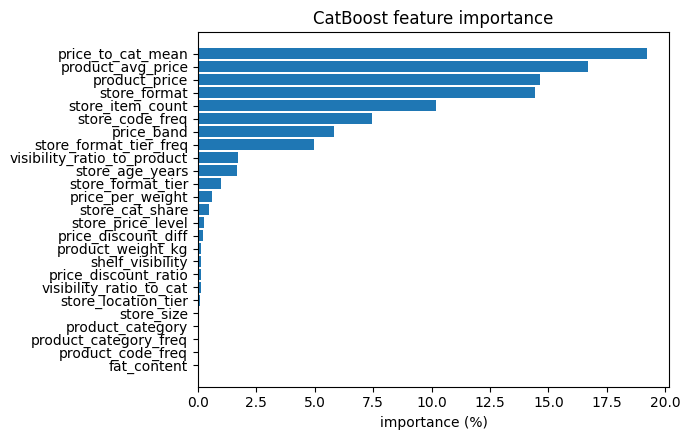

In [199]:
importance = pd.Series(cat_model.get_feature_importance(), index=X.columns).sort_values()

plt.figure(figsize=(7, 4.5))
plt.barh(importance.index, importance.values)
plt.title('CatBoost feature importance')
plt.xlabel('importance (%)')
plt.tight_layout()
plt.show()

`product_price` and `store_code` carry almost all of the importance, and the rest of the store columns (`store_format`, `store_location_tier`, `store_format_tier`, `store_size`, `store_age_years`) share what is left, because they all describe the same 10 stores. This matches what I found in section 3: price and the identity of the store are what actually drive sales.

##  LightGBM

Now I am going to be using another model - LightGBM. It uses the same folds as CatBoost.

In [200]:
import lightgbm as lgb

X_lgb = X.copy()
test_x_lgb = test_x.copy()

for col in categorical_columns:
    cats = sorted(all_data[col].unique())
    X_lgb[col] = pd.Categorical(X_lgb[col], categories=cats)
    test_x_lgb[col] = pd.Categorical(test_x_lgb[col], categories=cats)

rmse_scores_lgb = []

for fold, (train_idx, val_idx) in enumerate(folds):
    X_train, X_val = X_lgb.iloc[train_idx], X_lgb.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_lgb = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.028,
        max_depth=4,
        num_leaves=12,
        reg_alpha=4,
        reg_lambda=3,
        random_state=42,
        verbosity=-1
    )
    model_lgb.fit(X_train, y_train)

    preds = model_lgb.predict(X_val)
    fold_rmse = mean_squared_error(y_val, preds) ** 0.5
    rmse_scores_lgb.append(fold_rmse)
    print(f'Fold {fold+1} RMSE: {fold_rmse:.2f}')

rmse_scores_lgb = np.array(rmse_scores_lgb)
print(f'Mean RMSE: {rmse_scores_lgb.mean():.2f}')
print(f'Std RMSE: {rmse_scores_lgb.std():.2f}')
results['LightGBM'] = rmse_scores_lgb.mean()

Fold 1 RMSE: 1123.20
Fold 2 RMSE: 1041.17
Fold 3 RMSE: 1037.14
Fold 4 RMSE: 1067.72
Fold 5 RMSE: 1107.80
Fold 6 RMSE: 1078.73
Fold 7 RMSE: 1136.01
Fold 8 RMSE: 1116.83
Fold 9 RMSE: 1101.41
Fold 10 RMSE: 1018.20
Mean RMSE: 1082.82
Std RMSE: 38.51


LightGBM gets a mean RMSE of about **1082.82**, a bit behind CatBoost. On this dataset CatBoost handles the categorical columns better.

## Random Forest Model

In [201]:
from sklearn.ensemble import RandomForestRegressor

X_rf = train_encoded.drop(['id', 'total_sales', 'product_code','store_code'], axis=1)
y_rf = train_encoded['total_sales']

rmse_scores_rf = []

for fold, (train_idx, val_idx) in enumerate(folds):
    train_val_rf, test_val_rf = X_rf.iloc[train_idx], X_rf.iloc[val_idx]
    train_y_rf, test_y_rf = y_rf.iloc[train_idx], y_rf.iloc[val_idx]

    model_rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_split=3,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    model_rf.fit(train_val_rf, train_y_rf)

    preds = model_rf.predict(test_val_rf)
    fold_rmse = mean_squared_error(test_y_rf, preds) ** 0.5
    rmse_scores_rf.append(fold_rmse)
    print(f'Fold {fold+1} RMSE: {fold_rmse:.2f}')

rmse_scores_rf = np.array(rmse_scores_rf)
print(f'Mean RMSE: {rmse_scores_rf.mean():.2f}')
print(f'Std RMSE: {rmse_scores_rf.std():.2f}')
results['Random Forest'] = rmse_scores_rf.mean()

Fold 1 RMSE: 1124.22
Fold 2 RMSE: 1026.26
Fold 3 RMSE: 1060.58
Fold 4 RMSE: 1066.76
Fold 5 RMSE: 1105.72
Fold 6 RMSE: 1083.50
Fold 7 RMSE: 1130.23
Fold 8 RMSE: 1116.55
Fold 9 RMSE: 1103.59
Fold 10 RMSE: 1015.66
Mean RMSE: 1083.31
Std RMSE: 38.10


## XGBoost

In [202]:
from xgboost import XGBRegressor

def make_xgb():
    return XGBRegressor(
        n_estimators=200,
        learning_rate=0.020,
        max_depth=3,
        reg_alpha=3,
        reg_lambda=3,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        enable_categorical=True,
        tree_method='hist',
        random_state=42
    )

rmse_scores_xgb = []

for fold, (train_idx, val_idx) in enumerate(folds):
    X_train, X_val = X_lgb.iloc[train_idx], X_lgb.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model_xgb = make_xgb()
    model_xgb.fit(X_train, y_train)

    preds = model_xgb.predict(X_val)
    fold_rmse = mean_squared_error(y_val, preds) ** 0.5
    rmse_scores_xgb.append(fold_rmse)
    print(f'Fold {fold+1} RMSE: {fold_rmse:.2f}')

rmse_scores_xgb = np.array(rmse_scores_xgb)
print(f'Mean RMSE: {rmse_scores_xgb.mean():.2f}')
print(f'Std RMSE: {rmse_scores_xgb.std():.2f}')
results['XGBoost'] = rmse_scores_xgb.mean()

Fold 1 RMSE: 1108.02
Fold 2 RMSE: 1029.46
Fold 3 RMSE: 1044.02
Fold 4 RMSE: 1064.27
Fold 5 RMSE: 1097.80
Fold 6 RMSE: 1074.45
Fold 7 RMSE: 1130.20
Fold 8 RMSE: 1115.21
Fold 9 RMSE: 1101.20
Fold 10 RMSE: 1005.29
Mean RMSE: 1076.99
Std RMSE: 38.64


## Stacking

Now I perform stacking. Each model makes out of fold predictions (every row is predicted by a model that never saw it), and a Ridge model learns how to combine them.


In [203]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error

def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5

TE_COLS = [ 'product_category', 'store_format_tier']
M_SMOOTH = 10.0

def add_target_encoding(X_tr, X_va, X_te, y_tr):
    X_tr, X_va, X_te = X_tr.copy(), X_va.copy(), X_te.copy()
    global_mean = float(y_tr.mean())
    for col in TE_COLS:
        s_tr = X_tr[col].astype(str)
        counts = s_tr.value_counts()
        sums = pd.Series(y_tr.values, index=X_tr.index).groupby(s_tr).sum()
        te_map = ((sums + M_SMOOTH * global_mean) / (counts + M_SMOOTH)).to_dict()
        X_tr[f'{col}_te'] = X_tr[col].astype(str).map(te_map).fillna(global_mean).values
        X_va[f'{col}_te'] = X_va[col].astype(str).map(te_map).fillna(global_mean).values
        X_te[f'{col}_te'] = X_te[col].astype(str).map(te_map).fillna(global_mean).values
    return X_tr, X_va, X_te

oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_vol = np.zeros(len(X))

test_preds_cat = np.zeros(len(test_x))
test_preds_xgb = np.zeros(len(test_x_lgb))
test_preds_lgb = np.zeros(len(test_x_lgb))
test_preds_vol = np.zeros(len(test_x_lgb))

print(f" Training {len(folds)} folds..")

for fold, (train_idx, val_idx) in enumerate(folds):
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_tr_c, X_va_c, X_te_c = add_target_encoding(X.iloc[train_idx], X.iloc[val_idx], test_x, y_train)

    #CatBoost
    m_cat = CatBoostRegressor(**cat_params)
    m_cat.fit(X_tr_c, y_train)
    oof_cat[val_idx] = m_cat.predict(X_va_c)
    test_preds_cat += m_cat.predict(X_te_c) / len(folds)

    X_tr_x, X_va_x, X_te_x = add_target_encoding(X_lgb.iloc[train_idx], X_lgb.iloc[val_idx], test_x_lgb, y_train)

    #XGBoost
    m_xgb = make_xgb()
    m_xgb.fit(X_tr_x, y_train)
    oof_xgb[val_idx] = m_xgb.predict(X_va_x)
    test_preds_xgb += m_xgb.predict(X_te_x) / len(folds)

    #LightGBM
    m_lgb = lgb.LGBMRegressor(n_estimators=300, 
                              learning_rate=0.028, 
                              max_depth=4, 
                              num_leaves=12,
                              reg_alpha=4, 
                              reg_lambda=3, 
                              random_state=42, 
                              verbosity=-1)
    m_lgb.fit(X_tr_x, y_train)
    oof_lgb[val_idx] = m_lgb.predict(X_va_x)
    test_preds_lgb += m_lgb.predict(X_te_x) / len(folds)

    y_train_vol = y_train / X_lgb.iloc[train_idx]['product_price'].values
    m_vol = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.028, max_depth=4, num_leaves=12,
                              reg_alpha=4, reg_lambda=3, random_state=42, verbosity=-1)
    m_vol.fit(X_tr_x, y_train_vol)
    oof_vol[val_idx] = m_vol.predict(X_va_x) * X_lgb.iloc[val_idx]['product_price'].values
    test_preds_vol += (m_vol.predict(X_te_x) * test_x_lgb['product_price'].values) / len(folds)

    print(f"   Fold {fold+1:2d}/{len(folds)} complete.")

print(f"\nCatBoost alone RMSE:   {rmse(y, oof_cat):.2f}")
print(f"XGBoost alone RMSE:    {rmse(y, oof_xgb):.2f}")
print(f"LightGBM alone RMSE:   {rmse(y, oof_lgb):.2f}")
print(f"Volume model RMSE:     {rmse(y, oof_vol):.2f}")

naive_avg = (oof_cat + oof_xgb + oof_lgb + oof_vol) / 4
print(f"\nNaive 4-way average RMSE: {rmse(y, naive_avg):.2f}")

meta_X = np.column_stack([oof_cat, oof_xgb, oof_lgb, oof_vol])


stacked_cv = cross_val_predict(
    Ridge(alpha=50.0, positive=True, fit_intercept=True),
    meta_X, y, cv=KFold(5, shuffle=True, random_state=1)
)
print(f"Stacked (Ridge) RMSE, scored honestly: {rmse(y, stacked_cv):.2f}")
results['Stacking (Ridge)'] = rmse(y, stacked_cv)


meta_model = Ridge(alpha=50.0, positive=True, fit_intercept=True)
meta_model.fit(meta_X, y)
print(f"Learned weights -> CatBoost: {meta_model.coef_[0]:.3f}, XGBoost: {meta_model.coef_[1]:.3f}, "
      f"LightGBM: {meta_model.coef_[2]:.3f}, Volume: {meta_model.coef_[3]:.3f}")
print(f"Intercept: {meta_model.intercept_:.2f}")

stack_test_X = np.column_stack([test_preds_cat, test_preds_xgb, test_preds_lgb, test_preds_vol])
final_predictions = np.clip(meta_model.predict(stack_test_X), a_min=0, a_max=None)

 Training 10 folds..
   Fold  1/10 complete.
   Fold  2/10 complete.
   Fold  3/10 complete.
   Fold  4/10 complete.
   Fold  5/10 complete.
   Fold  6/10 complete.
   Fold  7/10 complete.
   Fold  8/10 complete.
   Fold  9/10 complete.
   Fold 10/10 complete.

CatBoost alone RMSE:   1073.97
XGBoost alone RMSE:    1077.89
LightGBM alone RMSE:   1083.44
Volume model RMSE:     1082.70

Naive 4-way average RMSE: 1076.10
Stacked (Ridge) RMSE, scored honestly: 1074.27
Learned weights -> CatBoost: 0.612, XGBoost: 0.386, LightGBM: 0.000, Volume: 0.022
Intercept: -43.94


In [204]:
submission = pd.DataFrame({'id': test_data['id'], 'total_sales': final_predictions})
submission.to_csv('submission_stack.csv', index=False)

assert len(submission) == 1705
assert submission['id'].is_unique and (submission['id'] == test_data['id']).all()
assert submission['total_sales'].notna().all() and (submission['total_sales'] >= 0).all()

print(submission.shape)
submission.head(10)

(1705, 2)


,id,total_sales
0,row_00009,2868.422694
1,row_00015,4460.518603
2,row_00019,2996.374783
3,row_00020,3157.395754
4,row_00023,2462.969200
5,row_00026,372.557339
6,row_00027,3901.729568
7,row_00033,3104.551083
8,row_00034,407.886878
9,row_00037,1975.931267


On their own: CatBoost RMSE 1073.97, XGBoost 1077.89, LightGBM 1083.44. The plain average of the three gives 1075.9, and the Ridge stack, scored properly this time, gives 1074.27 so the stack is really leaning on CatBoost and XGBoost.

## Summary of results

In [205]:
summary = pd.Series(results, name='CV RMSE').sort_values().round(2)
print(summary)

CatBoost            1073.52
Stacking (Ridge)    1074.27
XGBoost             1076.99
LightGBM            1082.82
Random Forest       1083.31
Name: CV RMSE, dtype: float64


### CatBoost and the Ridge stack are the best of the models I tried, both close to 1074. LightGBM and Random Forest trail behind. The gap between the best and worst here (about 10 points) is smaller than the standard deviation of a single model across folds (about 37 to 39 points), which tells me the models are all picking up roughly the same signal